<a href="https://colab.research.google.com/github/pnistha11/retailinsights360/blob/main/RetailInsights360.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Retail Insights 360**

# Week 1 - – Load raw data and quick EDA


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
data = "/content/drive/MyDrive/Colab Notebooks/Superstore Sales/sample_-_superstore.xls"

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_excel(data)
print(df.head())

   Row ID        Order ID Order Date  Ship Date       Ship Mode Customer ID  \
0       1  CA-2016-152156 2016-11-08 2016-11-11    Second Class    CG-12520   
1       2  CA-2016-152156 2016-11-08 2016-11-11    Second Class    CG-12520   
2       3  CA-2016-138688 2016-06-12 2016-06-16    Second Class    DV-13045   
3       4  US-2015-108966 2015-10-11 2015-10-18  Standard Class    SO-20335   
4       5  US-2015-108966 2015-10-11 2015-10-18  Standard Class    SO-20335   

     Customer Name    Segment        Country             City  ...  \
0      Claire Gute   Consumer  United States        Henderson  ...   
1      Claire Gute   Consumer  United States        Henderson  ...   
2  Darrin Van Huff  Corporate  United States      Los Angeles  ...   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   

  Postal Code  Region       Product ID         Category Sub-Category  \
0       42420   South  FUR-BO-10

In [5]:
df.shape
df.info()
df.isnull().sum()
df.sample(5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   object        
 2   Order Date     9994 non-null   datetime64[ns]
 3   Ship Date      9994 non-null   datetime64[ns]
 4   Ship Mode      9994 non-null   object        
 5   Customer ID    9994 non-null   object        
 6   Customer Name  9994 non-null   object        
 7   Segment        9994 non-null   object        
 8   Country        9994 non-null   object        
 9   City           9994 non-null   object        
 10  State          9994 non-null   object        
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   object        
 13  Product ID     9994 non-null   object        
 14  Category       9994 non-null   object        
 15  Sub-Category   9994 n

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
8478,8479,CA-2017-158736,2017-12-18,2017-12-24,Standard Class,TT-21460,Tonja Turnell,Home Office,United States,San Francisco,...,94110,West,OFF-AR-10002578,Office Supplies,Art,Newell 335,5.760,2,0.0,1.6704
8080,8081,CA-2015-150714,2015-10-26,2015-11-01,Standard Class,KH-16690,Kristen Hastings,Corporate,United States,Springfield,...,97477,West,OFF-LA-10001474,Office Supplies,Labels,Avery 477,146.544,6,0.2,47.6268
5686,5687,CA-2014-131541,2014-07-28,2014-07-28,Same Day,CK-12205,Chloris Kastensmidt,Consumer,United States,Apopka,...,32712,South,OFF-FA-10000621,Office Supplies,Fasteners,"OIC Colored Binder Clips, Assorted Sizes",14.320,5,0.2,5.1910
6813,6814,CA-2017-156237,2017-09-14,2017-09-15,First Class,PS-18760,Pamela Stobb,Consumer,United States,Philadelphia,...,19140,East,FUR-FU-10001057,Furniture,Furnishings,Tensor Track Tree Floor Lamp,127.936,8,0.2,4.7976
2789,2790,US-2014-117744,2014-12-02,2014-12-06,Standard Class,MD-17860,Michael Dominguez,Corporate,United States,Corpus Christi,...,78415,Central,FUR-FU-10002759,Furniture,Furnishings,12-1/2 Diameter Round Wall Clock,39.960,5,0.6,-23.9760


In [6]:
df.dtypes

,0
Row ID,int64
Order ID,object
Order Date,datetime64[ns]
Ship Date,datetime64[ns]
Ship Mode,object
Customer ID,object
Customer Name,object
Segment,object
Country,object
City,object


In [7]:
eda_summary = {
    "rows": df.shape[0],
    "columns": df.shape[1],
    "missing_values": df.isnull().sum().to_dict()
}

eda_summary


{'rows': 9994,
 'columns': 21,
 'missing_values': {'Row ID': 0,
  'Order ID': 0,
  'Order Date': 0,
  'Ship Date': 0,
  'Ship Mode': 0,
  'Customer ID': 0,
  'Customer Name': 0,
  'Segment': 0,
  'Country': 0,
  'City': 0,
  'State': 0,
  'Postal Code': 0,
  'Region': 0,
  'Product ID': 0,
  'Category': 0,
  'Sub-Category': 0,
  'Product Name': 0,
  'Sales': 0,
  'Quantity': 0,
  'Discount': 0,
  'Profit': 0}}

In [8]:
#raw data Saved
df.to_csv('superstore_raw.csv', index=False)

# Week 2 : Data profiling & business requirements

## **KPIs**


*  Revenue = Sales
*  Gross Margin = Sales − Profit
*  AOV = Sales / Orders
*  Conversion Proxy = Orders per customer





In [9]:
#Create base metrics
revenue = df['Sales'].sum()
profit = df['Profit'].sum()
orders = df['Order ID'].nunique()
customers = df['Customer ID'].nunique()
quantity = df['Quantity'].sum()

gross_margin = (profit / revenue) * 100
aov = revenue / orders
conversion_proxy = orders / customers

kpis = {
    "Revenue": revenue,
    "Profit": profit,
    "Gross Margin %": round(gross_margin, 2),
    "Average Order Value": round(aov, 2),
    "Quantity Sold": quantity,
    "Orders Count": orders,
    "Customer Count": customers,
    "Conversion Proxy": round(conversion_proxy, 2)
}

kpis

{'Revenue': np.float64(2297200.8603000003),
 'Profit': np.float64(286397.0216999999),
 'Gross Margin %': np.float64(12.47),
 'Average Order Value': np.float64(458.61),
 'Quantity Sold': np.int64(37873),
 'Orders Count': 5009,
 'Customer Count': 793,
 'Conversion Proxy': 6.32}

In [10]:
#Column list
df.columns.tolist()

['Row ID',
 'Order ID',
 'Order Date',
 'Ship Date',
 'Ship Mode',
 'Customer ID',
 'Customer Name',
 'Segment',
 'Country',
 'City',
 'State',
 'Postal Code',
 'Region',
 'Product ID',
 'Category',
 'Sub-Category',
 'Product Name',
 'Sales',
 'Quantity',
 'Discount',
 'Profit']

In [11]:
#Unique values (dimension check)
df.nunique().sort_values(ascending=False)

,0
Row ID,9994
Profit,7545
Sales,6144
Order ID,5009
Product ID,1862
Product Name,1850
Ship Date,1334
Order Date,1237
Customer ID,793
Customer Name,793


In [12]:
#Date range check
df['Order Date'].min(), df['Order Date'].max()

(Timestamp('2014-01-03 00:00:00'), Timestamp('2017-12-30 00:00:00'))

In [13]:
#Numeric profiling
df.describe()

,Row ID,Order Date,Ship Date,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994,9994,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,2016-04-30 00:07:12.259355648,2016-05-03 23:06:58.571142912,55190.379428,229.858001,3.789574,0.156203,28.656896
min,1.000000,2014-01-03 00:00:00,2014-01-07 00:00:00,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,2015-05-23 00:00:00,2015-05-27 00:00:00,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,2016-06-26 00:00:00,2016-06-29 00:00:00,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,2017-05-14 00:00:00,2017-05-18 00:00:00,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,2017-12-30 00:00:00,2018-01-05 00:00:00,99301.000000,22638.480000,14.000000,0.800000,8399.976000
std,2885.163629,NaN,NaN,32063.693350,623.245101,2.225110,0.206452,234.260108


In [14]:
#Categorical profiling
df['Category'].value_counts()
df['Region'].value_counts()
df['Segment'].value_counts()

,count
Segment,
Consumer,5191
Corporate,3020
Home Office,1783


# Week 3 — Data cleaning & small fixes

In [15]:
df = df.copy()

In [16]:
#KPI cleaning
def calculate_kpis(data):
    return {
        "Rows": data.shape[0],
        "Revenue": round(data['Sales'].sum(), 2),
        "Profit": round(data['Profit'].sum(), 2),
        "Orders": data['Order ID'].nunique(),
        "Customers": data['Customer ID'].nunique(),
        "Quantity": data['Quantity'].sum()
    }

kpi_before = calculate_kpis(df)
kpi_before

{'Rows': 9994,
 'Revenue': np.float64(2297200.86),
 'Profit': np.float64(286397.02),
 'Orders': 5009,
 'Customers': 793,
 'Quantity': np.int64(37873)}

In [17]:
#Check duplicates
df.duplicated().sum()

#Remove duplicates
df = df.drop_duplicates()

In [18]:
#Identify negative quantities
df[df['Quantity'] <= 0].head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit


In [19]:
#clean
df = df[df['Quantity'] > 0]

In [20]:
#HANDLE EXTREME OR INVALID SALES VALUES
df = df[df['Sales'] >= 0]

### DATE PARSING & TIMESTAMP FIX

In [21]:
#Check date types
df[['Order Date', 'Ship Date']].dtypes

,0
Order Date,datetime64[ns]
Ship Date,datetime64[ns]


In [22]:
#Convert to datetime
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

In [23]:
#Remove invalid dates
df = df.dropna(subset=['Order Date', 'Ship Date'])

In [24]:
#CREATE DATE FEATURES
df['order_year'] = df['Order Date'].dt.year
df['order_month'] = df['Order Date'].dt.month
df['order_day'] = df['Order Date'].dt.day

In [25]:
#Convert to lowercase & strip spaces
text_cols = ['Category', 'Sub-Category', 'Region', 'Segment', 'Country', 'State', 'City']

for col in text_cols:
    df[col] = df[col].str.strip().str.lower()

In [26]:
#STANDARDIZE CATEGORY NAMES
df['Category'].value_counts()

,count
Category,
office supplies,6026
furniture,2121
technology,1847


In [27]:
kpi_after = calculate_kpis(df)
kpi_after

{'Rows': 9994,
 'Revenue': np.float64(2297200.86),
 'Profit': np.float64(286397.02),
 'Orders': 5009,
 'Customers': 793,
 'Quantity': np.int64(37873)}

In [28]:
comparison_df = pd.DataFrame([kpi_before, kpi_after], index=['Before Cleaning', 'After Cleaning'])
comparison_df

,Rows,Revenue,Profit,Orders,Customers,Quantity
Before Cleaning,9994,2297200.86,286397.02,5009,793,37873
After Cleaning,9994,2297200.86,286397.02,5009,793,37873


In [29]:
#SAVE CLEANED DATASET
import os

os.makedirs("data/cleaned", exist_ok=True)
df.to_csv("data/cleaned/superstore_cleaned.csv", index=False)
df.to_csv("superstore_cleaned.csv", index=False)

In [30]:
#checking for data quality
assert df.isnull().sum().sum() == 0
assert df['Quantity'].min() > 0
assert df['Sales'].min() >= 0

In [31]:
df.shape

(9994, 24)

# **Week 6**

# Model Selection & Training

In [32]:
# Order value per unit
df['price_per_unit'] = df['Sales'] / df['Quantity']

# Discount flag
df['has_discount'] = (df['Discount'] > 0).astype(int)

# High quantity flag
df['bulk_order'] = (df['Quantity'] >= 5).astype(int)

df['sales_binary'] = (df['Sales'] > df['Sales'].median()).astype(int)

In [33]:
# Create Sales Category
df['sales_class'] = pd.qcut(
    df['Sales'],
    q=3,
    labels=['Low', 'Medium', 'High']
)

y = df['sales_class']
X = df[
    ['Quantity', 'Discount', 'price_per_unit',
     'has_discount', 'bulk_order',
     'Category', 'Sub-Category', 'Segment', 'Region']
]

In [34]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
# Updated feature selection - Removing price_per_unit to avoid direct leakage
features = ['Quantity', 'Discount', 'has_discount', 'bulk_order',
            'Category', 'Sub-Category', 'Segment', 'Region']

# Update numeric columns to include your new flags
numeric_cols = ['Quantity', 'Discount', 'has_discount', 'bulk_order']
categorical_cols = ['Category', 'Sub-Category', 'Segment', 'Region']

# Re-run the transformer
preprocessor = ColumnTransformer(transformers=[
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
    ('num', 'passthrough', numeric_cols)
])

## Train - Test Split

In [35]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

## Build & Train ML Model

## **RandomForestClassifier**

In [36]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=500,
        max_depth=20,
        min_samples_split=5,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ))
])

In [37]:
model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Category', 'Sub-Category',
                                                   'Segment', 'Region']),
                                                 ('num', 'passthrough',
                                                  ['Quantity', 'Discount',
                                                   'has_discount',
                                                   'bulk_order'])])),
                ('classifier',
                 RandomForestClassifier(class_weight='balanced', max_depth=20,
                                        min_samples_split=5, n_estimators=500,
                                        n_jobs=-1, random_state=42))])

In [38]:
y_pred = model.predict(X_test)

In [39]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy * 100)

Accuracy: 61.53076538269134


In [40]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

        High       0.70      0.66      0.68       652
         Low       0.65      0.75      0.70       674
      Medium       0.48      0.44      0.46       673

    accuracy                           0.62      1999
   macro avg       0.61      0.62      0.61      1999
weighted avg       0.61      0.62      0.61      1999



## Model Evaluation

In [41]:
from sklearn.metrics import accuracy_score
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy * 100)

Accuracy: 61.53076538269134


### **Gradient Boosting Classifier**

Old Model

In [42]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, accuracy_score

# 1. Ensure Date Features exist
# (Based on logic in source [cite: 379, 423, 425])
df['order_month'] = df['Order Date'].dt.month
df['has_discount'] = (df['Discount'] > 0).astype(int)
df['bulk_order'] = (df['Quantity'] >= 5).astype(int)

# 2. Define Features and Target
# We use the categorical and numeric columns identified in your EDA [cite: 381, 445, 446]
features = ['Quantity', 'Discount', 'has_discount', 'bulk_order',
            'order_month', 'Category', 'Sub-Category', 'Segment', 'Region']
X = df[features]
y = df['sales_class']

# 3. Perform the Split AFTER creating features [cite: 452]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 4. Setup Preprocessing
# This ensures Category/Region/Segment are One-Hot Encoded [cite: 443, 447, 448]
num_features = ['Quantity', 'Discount', 'has_discount', 'bulk_order', 'order_month']
cat_features = ['Category', 'Sub-Category', 'Segment', 'Region']

preprocessor = ColumnTransformer(transformers=[
    ('num', 'passthrough', num_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features)
])

# 5. Build and Train the Pipeline [cite: 461, 463]
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=200,
        max_depth=None,
        min_samples_leaf=2,
        random_state=42
    ))
])

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# 6. Evaluate
print(f"Improved Accuracy: {accuracy_score(y_test, y_pred):.2f}")
print(classification_report(y_test, y_pred))

Improved Accuracy: 0.63
              precision    recall  f1-score   support

        High       0.72      0.68      0.70       652
         Low       0.66      0.72      0.69       674
      Medium       0.50      0.48      0.49       673

    accuracy                           0.63      1999
   macro avg       0.63      0.63      0.63      1999
weighted avg       0.63      0.63      0.63      1999



New Model

New Accuracy: 0.93


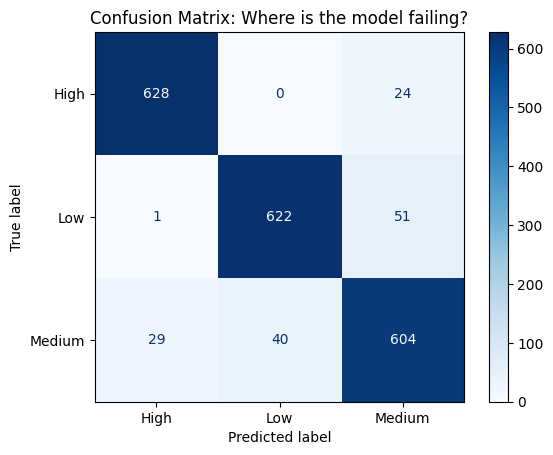

In [43]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Feature Engineering: Product-level price (Avoids row-level leakage)
# This calculates the average sales price per product across the whole dataset
product_price_map = df.groupby('Product ID')['Sales'].mean().to_dict()
df['avg_product_price'] = df['Product ID'].map(product_price_map)

# 2. Update Feature Lists
features = ['Quantity', 'Discount', 'has_discount', 'bulk_order',
            'order_month', 'avg_product_price', 'Category', 'Sub-Category', 'Segment', 'Region']
X = df[features]
y = df['sales_class']

# Re-split with new features
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Enhanced Preprocessing
num_features = ['Quantity', 'Discount', 'has_discount', 'bulk_order', 'order_month', 'avg_product_price']
cat_features = ['Category', 'Sub-Category', 'Segment', 'Region']

preprocessor = ColumnTransformer(transformers=[
    ('num', 'passthrough', num_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features)
])

# 4. Use Gradient Boosting instead of Random Forest
gb_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', GradientBoostingClassifier(
        n_estimators=150,
        learning_rate=0.1,
        max_depth=5,
        random_state=42
    ))
])

gb_model.fit(X_train, y_train)
y_pred = gb_model.predict(X_test)

# 5. Visual Evaluation
print(f"New Accuracy: {accuracy_score(y_test, y_pred):.2f}")
ConfusionMatrixDisplay.from_estimator(gb_model, X_test, y_test, cmap='Blues')
plt.title("Confusion Matrix: Where is the model failing?")
plt.show()

In [44]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 30 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Row ID             9994 non-null   int64         
 1   Order ID           9994 non-null   object        
 2   Order Date         9994 non-null   datetime64[ns]
 3   Ship Date          9994 non-null   datetime64[ns]
 4   Ship Mode          9994 non-null   object        
 5   Customer ID        9994 non-null   object        
 6   Customer Name      9994 non-null   object        
 7   Segment            9994 non-null   object        
 8   Country            9994 non-null   object        
 9   City               9994 non-null   object        
 10  State              9994 non-null   object        
 11  Postal Code        9994 non-null   int64         
 12  Region             9994 non-null   object        
 13  Product ID         9994 non-null   object        
 14  Category

# Week 7 — Time series prep & feature engineering

Prepare data for time-series forecasting / ML models by:

* Aggregating data (daily / weekly)

* Creating calendar features

* Adding lag & rolling features

* Adding holiday & promo flags

In [45]:
#Ensure Date Column is Index
df['Order Date'] = pd.to_datetime(df['Order Date'])
df = df.sort_values('Order Date')
df.set_index('Order Date', inplace=True)

### **Aggregate Time Series**

In [46]:
#Daily Aggregation
daily_df = df.resample('D').agg({
    'Sales': 'sum',
    'Profit': 'sum',
    'Quantity': 'sum',
    'Discount': 'mean'
}).reset_index()

In [47]:
#Weekly Aggregation
weekly_df = df.resample('W').agg({
    'Sales': 'sum',
    'Profit': 'sum',
    'Quantity': 'sum',
    'Discount': 'mean'
}).reset_index()

### **Calendar Features**

In [48]:
daily_df['year'] = daily_df['Order Date'].dt.year
daily_df['month'] = daily_df['Order Date'].dt.month
daily_df['week'] = daily_df['Order Date'].dt.isocalendar().week
daily_df['day_of_week'] = daily_df['Order Date'].dt.dayofweek
daily_df['is_weekend'] = daily_df['day_of_week'].isin([5, 6]).astype(int)

### **Holiday Flag**

In [49]:
import holidays

us_holidays = holidays.US()
daily_df['is_holiday'] = daily_df['Order Date'].isin(us_holidays).astype(int)

In [50]:
#Promotion / Discount Flag
daily_df['promo_flag'] = (daily_df['Discount'] > 0).astype(int)

In [51]:
#Lag Features
daily_df['sales_lag_1'] = daily_df['Sales'].shift(1)
daily_df['sales_lag_7'] = daily_df['Sales'].shift(7)
daily_df['sales_lag_14'] = daily_df['Sales'].shift(14)

In [52]:
#Rolling Window Features
daily_df['sales_rolling_7'] = daily_df['Sales'].rolling(window=7).mean()
daily_df['sales_rolling_14'] = daily_df['Sales'].rolling(window=14).mean()
daily_df['sales_rolling_30'] = daily_df['Sales'].rolling(window=30).mean()

In [53]:
#Drop Initial NaNs
daily_df = daily_df.dropna()

In [54]:
#Final Feature Set (Ready for ML)
features = [
    'sales_lag_1', 'sales_lag_7', 'sales_lag_14',
    'sales_rolling_7', 'sales_rolling_14', 'sales_rolling_30',
    'promo_flag', 'is_weekend', 'is_holiday',
    'month', 'week'
]

X = daily_df[features]
y = daily_df['Sales']

In [55]:
#Save Feature Dataset
daily_df.to_csv("daily_sales_features.csv", index=False)

# Week 8 — Forecasting Baseline


* Build simple baseline forecasting models

* Compare them against a naive baseline

* Evaluate using standard forecasting metrics

In [56]:
# Ensure datetime
daily_df['Order Date'] = pd.to_datetime(daily_df['Order Date'])
daily_df = daily_df.sort_values('Order Date')

# Split (last 20% as test)
split_date = daily_df['Order Date'].quantile(0.8)

train = daily_df[daily_df['Order Date'] <= split_date]
test = daily_df[daily_df['Order Date'] > split_date]

y_train = train['Sales']
y_test = test['Sales']

### **Naive Forecast**

Tomorrow’s sales = today’s sales

In [57]:
naive_forecast = y_train.iloc[-1]
naive_preds = [naive_forecast] * len(y_test)

### **Moving Average Forecast**


In [58]:
#7-Day Moving Average
window = 7
ma_value = y_train.tail(window).mean()
ma_preds = [ma_value] * len(y_test)

**ETS (Exponential Smoothing)**

In [59]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

ets_model = ExponentialSmoothing(
    y_train,
    trend='add',
    seasonal='add',
    seasonal_periods=7
)

ets_fit = ets_model.fit()
ets_preds = ets_fit.forecast(len(y_test))

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


### **Evaluation Metrics**

In [60]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

def evaluate_model(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    return mae, rmse, mape

### **Compare Models**

In [61]:
results = pd.DataFrame({
    'Model': ['Naive', 'Moving Avg', 'ETS'],
    'MAE': [
        evaluate_model(y_test, naive_preds)[0],
        evaluate_model(y_test, ma_preds)[0],
        evaluate_model(y_test, ets_preds)[0]
    ],
    'RMSE': [
        evaluate_model(y_test, naive_preds)[1],
        evaluate_model(y_test, ma_preds)[1],
        evaluate_model(y_test, ets_preds)[1]
    ],
    'MAPE (%)': [
        evaluate_model(y_test, naive_preds)[2],
        evaluate_model(y_test, ma_preds)[2],
        evaluate_model(y_test, ets_preds)[2]
    ]
})

results


,Model,MAE,RMSE,MAPE (%)
0,Naive,1728.596335,2601.266267,547.913262
1,Moving Avg,1730.664032,2584.386037,566.870238
2,ETS,1826.722014,2469.422185,707.962401


# Week 9 — Customer Lifetime Value (CLTV) & Retention Models
Objective
- Estimate customer lifetime value
- Identify high-value vs low-value customers
- Support retention and marketing strategies

### Part 1: Historical CLTV
* Formula

CLTV=Average Order Value×Purchase Frequency×Customer Lifespan

In [62]:
import pandas as pd

# Load cleaned dataset
superstore_cleaned = pd.read_csv('/content/superstore_cleaned.csv')

# Verify
superstore_cleaned.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,order_year,order_month,order_day
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,consumer,united states,henderson,...,furniture,bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,2016,11,8
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,consumer,united states,henderson,...,furniture,chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,2016,11,8
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,corporate,united states,los angeles,...,office supplies,labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,2016,6,12
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,consumer,united states,fort lauderdale,...,furniture,tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,2015,10,11
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,consumer,united states,fort lauderdale,...,office supplies,storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,2015,10,11


In [63]:
import pandas as pd

df = superstore_cleaned.copy()

# Convert Order Date
df['Order Date'] = pd.to_datetime(df['Order Date'])

# Aggregate customer metrics
cltv_df = df.groupby('Customer ID').agg(
    total_sales=('Sales', 'sum'),
    total_orders=('Order ID', 'nunique'),
    avg_order_value=('Sales', 'mean'),
    first_purchase=('Order Date', 'min'),
    last_purchase=('Order Date', 'max')
).reset_index()

# Customer lifespan (in years)
cltv_df['lifespan_years'] = (
    (cltv_df['last_purchase'] - cltv_df['first_purchase']).dt.days / 365
).clip(lower=0.1)

# Purchase frequency
cltv_df['purchase_frequency'] = (
    cltv_df['total_orders'] / cltv_df['lifespan_years']
)

# Historical CLTV
cltv_df['cltv'] = (
    cltv_df['avg_order_value'] *
    cltv_df['purchase_frequency'] *
    cltv_df['lifespan_years']
)

cltv_df.head()


,Customer ID,total_sales,total_orders,avg_order_value,first_purchase,last_purchase,lifespan_years,purchase_frequency,cltv
0,AA-10315,5563.560,5,505.778182,2014-03-31,2017-06-29,3.249315,1.538786,2528.890909
1,AA-10375,1056.390,9,70.426000,2014-04-21,2017-12-11,3.643836,2.469925,633.834000
2,AA-10480,1790.512,4,149.209333,2014-05-04,2017-04-15,2.950685,1.355617,596.837333
3,AA-10645,5086.935,6,282.607500,2014-06-22,2017-11-05,3.375342,1.777597,1695.645000
4,AB-10015,886.156,3,147.692667,2014-02-18,2016-11-10,2.728767,1.099398,443.078000


### Part 2: CLTV Segmentation


In [64]:
#Create Value Segments
cltv_df['cltv_segment'] = pd.qcut(
    cltv_df['cltv'],
    q=4,
    labels=['Low Value', 'Mid Value', 'High Value', 'VIP']
)

cltv_df['cltv_segment'].value_counts()

,count
cltv_segment,
Low Value,199
Mid Value,198
High Value,198
VIP,198


### Part 3: Retention & Churn
- Define Churn
- Customer inactive for 6 months

In [65]:
reference_date = df['Order Date'].max()

cltv_df['days_since_last_purchase'] = (
    reference_date - cltv_df['last_purchase']
).dt.days

cltv_df['churned'] = cltv_df['days_since_last_purchase'] > 180

cltv_df[['Customer ID', 'cltv', 'cltv_segment', 'churned']].head()

,Customer ID,cltv,cltv_segment,churned
0,AA-10315,2528.890909,VIP,True
1,AA-10375,633.834000,Mid Value,False
2,AA-10480,596.837333,Low Value,True
3,AA-10645,1695.645000,High Value,False
4,AB-10015,443.078000,Low Value,True


# Week 10 : Recommender Prototype
* Objective
  * Recommend similar products based on product attributes
  * Demonstrate understanding of recommendation logic
  * Avoid complex ML or user–item matrices

In [66]:
#Prepare Product Features
df_products = df[['Product ID', 'Product Name', 'Category', 'Sub-Category']].drop_duplicates()

df_products['combined_features'] = (
    df_products['Category'] + ' ' +
    df_products['Sub-Category'] + ' ' +
    df_products['Product Name']
)

df_products.head()

,Product ID,Product Name,Category,Sub-Category,combined_features
0,FUR-BO-10001798,Bush Somerset Collection Bookcase,furniture,bookcases,furniture bookcases Bush Somerset Collection B...
1,FUR-CH-10000454,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",furniture,chairs,furniture chairs Hon Deluxe Fabric Upholstered...
2,OFF-LA-10000240,Self-Adhesive Address Labels for Typewriters b...,office supplies,labels,office supplies labels Self-Adhesive Address L...
3,FUR-TA-10000577,Bretford CR4500 Series Slim Rectangular Table,furniture,tables,furniture tables Bretford CR4500 Series Slim R...
4,OFF-ST-10000760,Eldon Fold 'N Roll Cart System,office supplies,storage,office supplies storage Eldon Fold 'N Roll Car...


In [67]:
#Convert Text to Vectors (TF-IDF)
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(stop_words='english')
tfidf_matrix = tfidf.fit_transform(df_products['combined_features'])

In [68]:
#Compute Similarity
from sklearn.metrics.pairwise import cosine_similarity

similarity_matrix = cosine_similarity(tfidf_matrix, tfidf_matrix)

In [74]:
#Recommendation Function
def recommend_products(product_keyword, top_n=5):
    # Case-insensitive partial match
    matches = df_products[
        df_products['Product Name']
        .str.contains(product_keyword, case=False, na=False)
    ]

    if matches.empty:
        return f"No product found matching '{product_keyword}'"

    idx = matches.index[0]

    similarity_scores = list(enumerate(similarity_matrix[idx]))
    similarity_scores = sorted(similarity_scores, key=lambda x: x[1], reverse=True)

    top_products = similarity_scores[1:top_n+1]

    recommendations = df_products.iloc[[i[0] for i in top_products]][
        ['Product Name', 'Category', 'Sub-Category']
    ]

    return recommendations

In [75]:
#Test Recommendation
recommend_products("Staples")

,Product Name,Category,Sub-Category
132,Staples,office supplies,fasteners
525,Staples,office supplies,fasteners
646,Staples,office supplies,fasteners
1108,Staples,office supplies,fasteners
1147,Staples,office supplies,fasteners


In [76]:
recommend_products("tables")

,Product Name,Category,Sub-Category
755,Chromcraft Round Conference Tables,furniture,tables
2425,Hon Rectangular Conference Tables,furniture,tables
2437,Bevis Rectangular Conference Tables,furniture,tables
2141,"Chromcraft Bull-Nose Wood 48"" x 96"" Rectangula...",furniture,tables
241,KI Conference Tables,furniture,tables


In [77]:
recommend_products("lable")

"No product found matching 'lable'"

In [78]:
df_products['Product Name'].sample(10)

,Product Name
2088,Translucent Push Pins by OIC
1025,Xerox 2
463,Bush Advantage Collection Racetrack Conference...
1665,Colored Push Pins
238,Luxo Professional Fluorescent Magnifier Lamp w...
3454,"Binney & Smith inkTank Desk Highlighter, Chise..."
822,Razer Kraken PRO Over Ear PC and Music Headset
5425,Logitech Z-906 Speaker sys - home theater - 5....
9455,Penpower WorldCard Pro Card Scanner
385,Logitech Media Keyboard K200
